In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

from armored.models import *
from armored.preprocessing import *

import itertools

from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

In [2]:
# data with initial and end point measurements
df_exp0 = pd.read_csv("data/exp0/exp0_metabolites.csv")
df_exp1 = pd.read_csv("data/exp1/exp1_metabolites.csv")
df_exp2 = pd.read_csv("data/exp2/exp2_metabolites.csv")
df_exp3 = pd.read_csv("data/exp3/exp3_metabolites.csv")
df_exp4a = pd.read_csv("data/exp4/exp4_metabolites_best_reps.csv")
df_exp4b = pd.read_csv("data/exp4/exp4_metabolites_new_best.csv")
df_exp4c = pd.read_csv("data/exp4/exp4_metabolites_new_worst.csv")

df = pd.concat((df_exp1, df_exp2, df_exp3))

In [3]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))
system_variables

array(['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs',
       'CHabs', 'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs',
       'RIabs', 'pH', 'Lactate', 'Butyrate', 'Acetate', 'AcGum', 'ArGal',
       'Inulin', 'Pectin', 'Starch', 'Xylan'], dtype='<U8')

In [4]:
# scale data 
scaler = MinMaxScaler(observed, system_variables)
scaler.fit(df)
df_scaled = scaler.transform(df.copy())

# format data into matrix [n_samples, n_timepoints, dt+n_outputs+n_controls]
data = format_data(df.copy(), species, metabolites, controls, observed=observed)
data_scaled = format_data(df_scaled, species, metabolites, controls, observed=observed)

# instantiate model
brnn = miRNN(n_species=len(species), 
             n_metabolites=len(metabolites), 
             n_controls=len(controls), 
             n_hidden=16)

# fit model
brnn.fit(data_scaled, evd_tol=1e-3)

Total measurements: 23706, Number of parameters: 1011, Initial regularization: 0.00e+00
Loss: 1332.088, Residuals: -0.01021
Loss: 1261.234, Residuals: -0.00522
Loss: 1242.892, Residuals: -0.00197
Loss: 1208.496, Residuals: -0.00227
Loss: 1069.285, Residuals: 0.00297
Loss: 1003.491, Residuals: -0.00171
Loss: 912.087, Residuals: 0.00086
Loss: 898.744, Residuals: 0.00022
Loss: 847.654, Residuals: 0.00006
Loss: 823.667, Residuals: 0.00049
Loss: 777.921, Residuals: 0.00022
Loss: 727.723, Residuals: -0.00137
Loss: 720.566, Residuals: -0.00182
Loss: 713.631, Residuals: -0.00021
Loss: 700.960, Residuals: -0.00008
Loss: 675.142, Residuals: -0.00009
Loss: 638.297, Residuals: 0.00048
Loss: 634.456, Residuals: 0.00004
Loss: 627.762, Residuals: -0.00014
Loss: 616.040, Residuals: -0.00013
Loss: 610.238, Residuals: -0.00090
Loss: 600.730, Residuals: -0.00092
Loss: 600.030, Residuals: -0.00083
Loss: 593.452, Residuals: -0.00089
Loss: 581.688, Residuals: -0.00104
Loss: 567.638, Residuals: -0.00154
Loss

In [77]:
predictions = brnn.predict(data_scaled)

In [78]:
# save predictions
pred_dfs = [] 
for (T, X, U, Y, exp_names), (_, preds, stdvs, exp_names_pred) in zip(data_scaled, predictions):

    # account for dilution factor 
    Y[:,0] /= 50
    preds[:,0] /=50
    
    # save species predictions for each experimental condition
    for i, exp_name in enumerate(exp_names):
        # init dataframe
        pred_df_exp = pd.DataFrame()

        # insert exp name
        pred_df_exp["Experiments"] = [exp_name]*len(T[i])
        pred_df_exp["Time"] = T[i]

        for j, s in enumerate(observed):
            pred_df_exp[s + " true"] = Y[i,:,j]
            pred_df_exp[s + " pred"] = preds[i,:,j]
            pred_df_exp[s + " stdv"] = stdvs[i,:,j]

        # append to test prediction dataframe
        pred_dfs.append(pred_df_exp)
pred_df = pd.concat(pred_dfs)

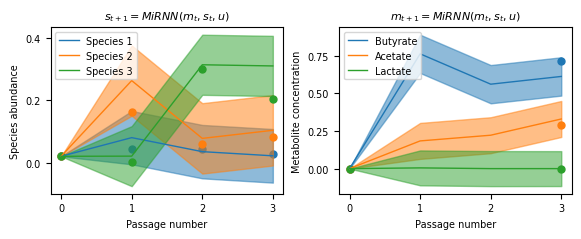

In [114]:
exp_plot = 'AC-BA-BH-BL-BU-CC-CH-DF-ER-FP-RI-5Inulin-1Pectin'
df_exp = pred_df.iloc[np.in1d(pred_df.Experiments.values, exp_plot)]

# passages
time = df_exp['Time'].values

# species to plot
plt.figure(figsize=(6, 2.5))
plt.subplot(1, 2, 1)
s_plot = ['ACabs', 'BUabs', 'BLabs']
for i, s in enumerate(s_plot):

    y_meas = df_exp[f'{s} true'].values
    y_pred = df_exp[f'{s} pred'].values
    y_stdv = df_exp[f'{s} stdv'].values

    plt.scatter(time, y_meas, c=f'C{i}', s=25)
    plt.plot(time, y_pred, c=f'C{i}', linewidth=1, label=f'Species {i+1}')
    plt.fill_between(time, y_pred-y_stdv, y_pred+y_stdv, alpha=.5, color=f'C{i}')
    
plt.legend(fontsize=7, loc='upper left')
plt.xticks([0, 1, 2, 3], fontsize=7)
plt.yticks(fontsize=7)
plt.xlabel("Passage number", fontsize=7)
plt.ylabel("Species abundance", fontsize=7)
plt.title(r"$s_{t+1} = MiRNN(m_t, s_t, u)$", fontsize=8)
    
plt.subplot(1, 2, 2)
s_plot = ['Butyrate', 'Acetate', 'Lactate']
for i, s in enumerate(s_plot):

    y_meas = df_exp[f'{s} true'].values
    y_pred = df_exp[f'{s} pred'].values
    y_stdv = df_exp[f'{s} stdv'].values 

    plt.scatter(time, y_meas, c=f'C{i}', s=25)
    plt.plot(time, y_pred, c=f'C{i}', linewidth=1, label=s)
    plt.fill_between(time, y_pred-y_stdv, y_pred+y_stdv, alpha=.5, color=f'C{i}')

# plt.title(exp_plot)
plt.legend(fontsize=7, loc='upper left')
plt.xticks([0, 1, 2, 3], fontsize=7)
plt.yticks(fontsize=7)
plt.xlabel("Passage number", fontsize=7)
plt.ylabel("Metabolite concentration", fontsize=7)
plt.title(r"$m_{t+1} = MiRNN(m_t, s_t, u)$", fontsize=8)

plt.tight_layout()
plt.savefig("figures/example_trajectory_dist.svg", dpi=300)
plt.show()